In [1]:
# =========================================
# H3 (Experiment 1): Lazare Needs Satisfaction
# DV: S_mean (post-only)
# IV: apology_type (healing / defensive / no_apology), scenario (1/2/3)
# Method: OLS (+ robust SE), planned contrasts, plot means + 95% CI
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import dmatrix

In [2]:
# -----------------------------
# 1) Load wide-format data
# -----------------------------
path = "experiment1_analysis_numeric.xlsx"  # upload this in Colab
df = pd.read_excel(path)

In [3]:
# Basic columns (adjust if your names differ)
for c in ["apology_type", "scenario"]:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")

In [4]:
# Ensure categorical
df["apology_type"] = df["apology_type"].astype("category")
df["scenario"] = df["scenario"].astype("category")

In [5]:
# Put healing as reference level (so defensive/no_apology are differences vs healing)
if "healing" in list(df["apology_type"].cat.categories):
    new_order = ["healing"] + [c for c in df["apology_type"].cat.categories if c != "healing"]
    df["apology_type"] = df["apology_type"].cat.reorder_categories(new_order, ordered=False)

In [6]:
# -----------------------------
# 2) Create S_mean if needed
# -----------------------------
if "S_mean" not in df.columns:
    # Try common naming patterns; adjust if your column names differ
    # Example: S1..S7
    s_cols = [c for c in df.columns if c.lower().startswith("s") and c[1:].isdigit()]
    if len(s_cols) >= 5:
        df["S_mean"] = df[s_cols].mean(axis=1)
        print("Created S_mean from:", s_cols)
    else:
        raise ValueError("S_mean not found, and could not infer S1..S7 columns. Please rename or edit the code.")

In [8]:
# -----------------------------
# 3) Fit OLS model (H3)
# -----------------------------
# Model: S_mean ~ apology_type + scenario
# Robust SE: HC3 (good default). You can switch to cluster if you prefer.
ols = smf.ols("S_mean ~ apology_type + scenario", data=df).fit(cov_type="HC3")

print("\n=== H3 OLS (robust HC3) ===")
print(ols.summary())


=== H3 OLS (robust HC3) ===
                            OLS Regression Results                            
Dep. Variable:                 S_mean   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     109.8
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.13e-46
Time:                        02:48:25   Log-Likelihood:                -282.80
No. Observations:                 178   AIC:                             575.6
Df Residuals:                     173   BIC:                             591.5
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [9]:
import os

# Define the filename for the OLS summary
output_filename = "ols_summary_h3.txt"

# Capture the OLS summary into a string
summary_str = ols.summary().as_text()

# Write the summary string to a .txt file
with open(output_filename, "w") as f:
    f.write(summary_str)

print(f"OLS summary saved to {os.path.abspath(output_filename)}")

OLS summary saved to /content/ols_summary_h3.txt


In [10]:
# -----------------------------
# 4) Planned contrasts (healing vs defensive; healing vs no_apology)
# -----------------------------
# With healing as reference:
#   apology_type[T.defensive] = defensive - healing
#   apology_type[T.no_apology] = no_apology - healing
# So H3 predicts BOTH are negative (healing higher).
print("\n=== Planned contrasts (vs healing) ===")

params = ols.params
cov = ols.cov_params()

def wald_test_linear(hypothesis_vector, label):
    # hypothesis_vector is a Series aligned with params index
    L = hypothesis_vector.values.reshape(1, -1)
    est = float(L @ params.values)
    se = float(np.sqrt(L @ cov.values @ L.T))
    z = est / se if se > 0 else np.nan
    # two-sided p
    from scipy import stats
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se
    print(f"{label}: estimate={est:.3f}, SE={se:.3f}, z={z:.3f}, p={p:.4g}, 95% CI [{ci_low:.3f}, {ci_high:.3f}]")

# defensive - healing
hv_def = pd.Series(0.0, index=params.index)
term_def = [t for t in params.index if "apology_type[T.defensive]" in t]
if term_def:
    hv_def[term_def[0]] = 1.0
    wald_test_linear(hv_def, "Defensive - Healing")
else:
    print("Could not find term: apology_type[T.defensive]")

# no_apology - healing
hv_no = pd.Series(0.0, index=params.index)
term_no = [t for t in params.index if "apology_type[T.no_apology]" in t]
if term_no:
    hv_no[term_no[0]] = 1.0
    wald_test_linear(hv_no, "No-apology - Healing")
else:
    print("Could not find term: apology_type[T.no_apology]")


=== Planned contrasts (vs healing) ===
Defensive - Healing: estimate=-2.435, SE=0.241, z=-10.085, p=0, 95% CI [-2.908, -1.962]
No-apology - Healing: estimate=-3.528, SE=0.193, z=-18.292, p=0, 95% CI [-3.906, -3.150]


/tmp/ipython-input-70256520.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  est = float(L @ params.values)
/tmp/ipython-input-70256520.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(np.sqrt(L @ cov.values @ L.T))


In [11]:
# -----------------------------
# 5) Estimated marginal means (EMMs) by apology_type (averaged over scenario)
#    + bootstrap 95% CI
# -----------------------------
def get_emm_by_type(result, df):
    ap_levels = list(df["apology_type"].cat.categories)
    scen_levels = list(df["scenario"].cat.categories)

    grid = []
    for ap in ap_levels:
        for sc in scen_levels:
            grid.append({"apology_type": ap, "scenario": sc})
    grid = pd.DataFrame(grid)

    X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
    pred = np.asarray(X @ result.params)
    grid["pred"] = pred

    emm = (
        grid.groupby("apology_type", as_index=False)["pred"]
            .mean()
            .rename(columns={"pred": "emm"})
    )
    return emm

emm = get_emm_by_type(ols, df)
print("\nEMMs (averaged over scenario):")
print(emm)

# Bootstrap CI (simple row bootstrap)
def bootstrap_emm(df, n_boot=5000, seed=123):
    rng = np.random.default_rng(seed)
    ap_levels = list(df["apology_type"].cat.categories)

    store = {ap: [] for ap in ap_levels}

    for b in range(n_boot):
        idx = rng.integers(0, len(df), size=len(df))
        df_b = df.iloc[idx].copy()

        # refit
        try:
            r = smf.ols("S_mean ~ apology_type + scenario", data=df_b).fit(cov_type="HC3")
        except Exception:
            continue

        emm_b = get_emm_by_type(r, df_b)
        for _, row in emm_b.iterrows():
            store[row["apology_type"]].append(row["emm"])

    rows = []
    for ap, vals in store.items():
        vals = np.array(vals, dtype=float)
        if len(vals) < 200:
            rows.append([ap, np.nan, np.nan, np.nan, len(vals)])
        else:
            rows.append([
                ap,
                float(np.mean(vals)),
                float(np.percentile(vals, 2.5)),
                float(np.percentile(vals, 97.5)),
                int(len(vals))
            ])
    out = pd.DataFrame(rows, columns=["apology_type", "mean", "ci_low", "ci_high", "n_success"])
    return out

boot = bootstrap_emm(df, n_boot=2000, seed=7)  # start with 2000; increase if you want
print("\nBootstrap EMMs + 95% CI:")
print(boot)

boot.to_csv("H3_bootstrap_emm_Smean.csv", index=False)

/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way


EMMs (averaged over scenario):
  apology_type       emm
0    defensive  2.746214
1      healing  5.180952
2   no_apology  1.652988


/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way


Bootstrap EMMs + 95% CI:
  apology_type      mean    ci_low   ci_high  n_success
0      healing  5.181477  4.902681  5.458753       2000
1    defensive  2.741993  2.385245  3.130854       2000
2   no_apology  1.650912  1.407857  1.907999       2000


/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way of writing 'design_info' (i.e. the .builder attribute just returns self)
  X = dmatrix(result.model.data.design_info.builder, grid, return_type="dataframe")
/tmp/ipython-input-375100939.py:15: DeprecationWarning: The DesignInfo.builder attribute is deprecated starting in patsy v0.4.0; distinct builder objects have been eliminated and design_info.builder is now just a long-winded way

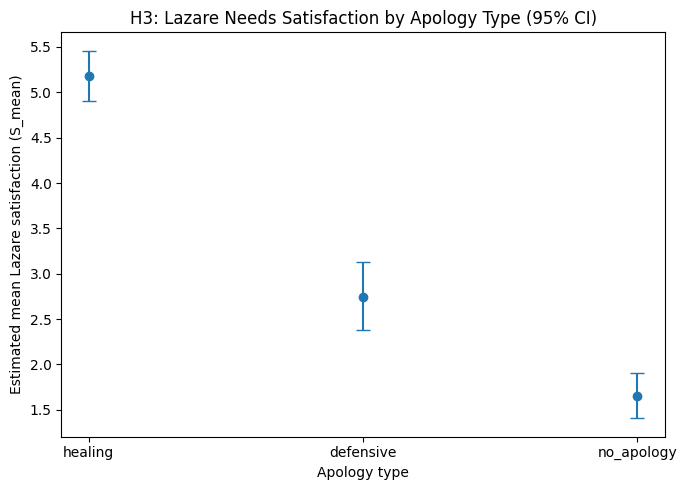


Saved files:
- H3_bootstrap_emm_Smean.csv
- H3_Smean_by_type.png


In [12]:
# -----------------------------
# 6) Plot means + 95% CI
# -----------------------------
# Sort by a meaningful order
order = ["healing", "defensive", "no_apology"]
boot["apology_type"] = pd.Categorical(boot["apology_type"], categories=order, ordered=True)
boot = boot.sort_values("apology_type")

x = np.arange(len(boot))
y = boot["mean"].values
yerr_low = y - boot["ci_low"].values
yerr_high = boot["ci_high"].values - y
yerr = np.vstack([yerr_low, yerr_high])

plt.figure(figsize=(7,5))
plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5)
plt.xticks(x, boot["apology_type"].astype(str).values)
plt.ylabel("Estimated mean Lazare satisfaction (S_mean)")
plt.xlabel("Apology type")
plt.title("H3: Lazare Needs Satisfaction by Apology Type (95% CI)")
plt.tight_layout()
plt.savefig("H3_Smean_by_type.png", dpi=200)
plt.show()

print("\nSaved files:")
print("- H3_bootstrap_emm_Smean.csv")
print("- H3_Smean_by_type.png")